# 04 — Descriptor-dimension selection

This notebook reads the manually selected fusion configuration from Notebook 03
and keeps its method and layer set fixed. It compares multi-level CLS
concatenation at 64-D, 128-D, 256-D, and 384-D using SfM validation only. It
writes the final-model lock consumed by Notebook 05.


In [1]:
# Run this first in every fresh Colab runtime. It intentionally does not use PYTHONPATH.
from datetime import datetime, timezone
from pathlib import Path
import importlib
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get('CBIR_REPO_URL', 'https://github.com/armin-faraji/LightweightCBIR.git')
REPO_REVISION = os.environ.get('CBIR_REPO_REVISION', 'main')
PROJECT_ROOT = Path('/content/lightweight-cbir')
if not PROJECT_ROOT.is_dir():
    subprocess.run(['git', 'clone', REPO_URL, str(PROJECT_ROOT)], check=True)
    subprocess.run(['git', '-C', str(PROJECT_ROOT), 'checkout', REPO_REVISION], check=True)
os.chdir(PROJECT_ROOT)
required_project_files = (
    PROJECT_ROOT / 'pyproject.toml',
    PROJECT_ROOT / 'src' / 'cbir' / '__init__.py',
    PROJECT_ROOT / 'src' / 'cbir' / 'artifacts.py',
)
missing_project_files = [
    str(path.relative_to(PROJECT_ROOT)) for path in required_project_files if not path.is_file()
]
if missing_project_files:
    raise RuntimeError(
        'The cloned repository does not contain the required project code: '
        + ', '.join(missing_project_files)
    )
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', '--no-deps', '--force-reinstall', '.'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'h5py', 'scipy', 'PyYAML', 'tqdm', 'matplotlib', 'Pillow'], check=True)

importlib.invalidate_caches()
import cbir
print('cbir package:', cbir.__file__)

from cbir.artifacts import create_artifact_run, make_artifact_run_id
from cbir.cloud import mount_colab_drive, runtime_report, write_runtime_report
from cbir.config import config_to_dict, load_project_config
from cbir.utils import stable_hash

PERSISTENT_ROOT = mount_colab_drive() / 'lightweight-cbir'
PERSISTENT_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('TORCH_HOME', str(PERSISTENT_ROOT / 'torch_hub'))
CONFIG_PATH = Path('configs/colab.yaml')
cfg = load_project_config(CONFIG_PATH)
environment = runtime_report(project_root=PROJECT_ROOT)
config_fingerprint = stable_hash(config_to_dict(cfg))
RUN_ID = make_artifact_run_id(
    notebook='04', git_sha=environment['git_sha'], config_fingerprint=config_fingerprint
)
ARTIFACT_RUN = create_artifact_run(
    PROJECT_ROOT / 'outputs',
    '04',
    run_id=RUN_ID,
    metadata={'git_sha': environment['git_sha'], 'config_fingerprint': config_fingerprint},
)
LOCAL_OUTPUT_DIR = ARTIFACT_RUN.local_dir
DRIVE_OUTPUT_ROOT = PERSISTENT_ROOT / 'notebook_outputs'
write_runtime_report(
    LOCAL_OUTPUT_DIR,
    project_root=PROJECT_ROOT,
    extra={'notebook': '04', 'config': str(CONFIG_PATH), 'stage': 'descriptor_dimension_selection'},
)
shutil.copy2(CONFIG_PATH, ARTIFACT_RUN.path_for('config.yaml'))
ARTIFACT_RUN.write_json('effective_config.json', config_to_dict(cfg))
print('Project:', PROJECT_ROOT)
print('Artifacts:', LOCAL_OUTPUT_DIR)
print('Descriptor-dimension selection runtime ready.')


Mounted at /content/drive
Project: /content/lightweight-cbir
Artifacts: /content/lightweight-cbir/outputs/04/20260805T110014Z__nb-04__git-c58b5ea65d19__cfg-d4f7521f8b98
Descriptor-dimension selection runtime ready.


## Restore the manual layer selection, metadata, and feature cache


In [2]:
from dataclasses import replace

from cbir.cache import FeatureShardReader
from cbir.cloud import publish_file, stage_file
from cbir.config import config_to_dict, train_fingerprint
from cbir.data.sfm import Sfm30kMetadata
from cbir.evaluation import evaluate_sfm_verified_pairs, final_cls_descriptors_from_cache
from cbir.fusion import build_descriptor_head
from cbir.plotting import HorizontalReference, SeriesData, plot_series
from cbir.training import HeadTrainer
from cbir.utils import atomic_write_json, read_json, seed_everything
from cbir.workflow import restore_complete_sfm_cache

LAYER_SELECTION_PATH = PERSISTENT_ROOT / 'selected' / 'layer_selection.json'
if not LAYER_SELECTION_PATH.is_file():
    raise FileNotFoundError('Notebook 03 has not recorded a manual layer selection: ' + str(LAYER_SELECTION_PATH))
layer_selection = read_json(LAYER_SELECTION_PATH)
if layer_selection.get('selected_on') != 'Manual student decision after SfM-30k validation inspection only':
    raise ValueError('Refusing a layer-selection record without the required SfM-only manual-selection provenance.')
SELECTED_LAYERS_ONE_BASED = tuple(int(layer) for layer in layer_selection['selected_layer_indices_one_based'])
SELECTED_HEAD_KIND = layer_selection.get('selected_head_kind')
SELECTED_GATE_MODE = layer_selection.get('selected_gate_mode')
if SELECTED_HEAD_KIND != 'cls_concat' or SELECTED_GATE_MODE is not None:
    raise ValueError('Notebook 04 is the CLS-concatenation dimension study; rerun the Notebook 03 selection cell with cls_concat_8_10_12.')

LOCAL_SFM_ROOT = cfg.sfm.metadata_path.parent
DRIVE_SFM_ROOT = PERSISTENT_ROOT / 'datasets' / 'sfm30k'
metadata_files = (cfg.sfm.metadata_path, cfg.sfm.names_clusters_path)
LOCAL_SFM_ROOT.mkdir(parents=True, exist_ok=True)
if not all(path is not None and path.is_file() for path in metadata_files):
    if not all(path is not None and (DRIVE_SFM_ROOT / path.name).is_file() for path in metadata_files):
        raise FileNotFoundError('SfM metadata is absent locally and on Drive; run Notebook 02 first.')
    for path in metadata_files:
        assert path is not None
        stage_file(DRIVE_SFM_ROOT / path.name, path)
if cfg.sfm.names_clusters_path is None:
    raise ValueError('configs/colab.yaml must define sfm.names_clusters_path')
metadata = Sfm30kMetadata.from_official_files(cfg.sfm.metadata_path, cfg.sfm.names_clusters_path)
cache_location = restore_complete_sfm_cache(cfg, metadata)
reader = FeatureShardReader(cache_location.local_dir)
# Dimension-selection training uses the same random pair access pattern as
# Notebook 03, so preload all local shards once and retain them in RAM.
reader.max_cached_shards = len(reader.manifest.shards)
warmup_ids = tuple(shard.image_ids[0] for shard in reader.manifest.shards)
_ = reader.fetch(
    warmup_ids,
    layer_indices=reader.manifest.layer_indices,
    local_kind=cfg.fusion.local_kind,
)
del warmup_ids, _
if layer_selection.get('cache_fingerprint') != reader.manifest.fingerprint:
    raise ValueError('Layer-selection record does not match the restored frozen cache.')
val_ids = metadata.image_ids('val')
val_cases = metadata.build_validation_cases()
baseline = final_cls_descriptors_from_cache(reader, val_ids)
baseline_report = evaluate_sfm_verified_pairs(baseline, val_ids, val_cases)
baseline_metrics = {
    'label': 'Final CLS — 384-D (frozen)',
    'descriptor_dimension': 384,
    'recall_at_1': baseline_report.recall_at_1,
    'recall_at_5': baseline_report.recall_at_5,
    'recall_at_10': baseline_report.recall_at_10,
    'mrr': baseline_report.mrr,
}
ARTIFACT_RUN.write_json('layer_selection_input.json', layer_selection)
ARTIFACT_RUN.write_json('baseline_metrics.json', baseline_metrics)
print('Selected fusion:', layer_selection['selected_experiment_label'])
print('Selected layer set:', SELECTED_LAYERS_ONE_BASED)
print('Using cache:', cache_location.local_dir)

DIMENSION_SPECS = tuple(
    {
        'name': f'cls_concat_{output_dim}',
        'label': f'Multi-level CLS concatenation ({", ".join(map(str, SELECTED_LAYERS_ONE_BASED))}) — {output_dim}-D',
        'output_dim': output_dim,
    }
    for output_dim in (64, 128, 256, 384)
)
PERSISTENT_CHECKPOINT_ROOT = PERSISTENT_ROOT / 'checkpoints' / '04' / ARTIFACT_RUN.run_id
histories = {}
dimension_results = {}


def selected_zero_based_layers():
    return tuple(layer - 1 for layer in SELECTED_LAYERS_ONE_BASED)


def write_dimension_summary():
    ARTIFACT_RUN.write_json('dimension_summary.json', {
        'layer_selection': layer_selection,
        'baseline': baseline_metrics,
        'experiments': dimension_results,
    })


def run_dimension_experiment(name):
    if name in dimension_results:
        return histories[name], dimension_results[name]
    spec = next(item for item in DIMENSION_SPECS if item['name'] == name)
    fusion_cfg = replace(
        cfg.fusion,
        layer_indices=selected_zero_based_layers(),
        output_dim=spec['output_dim'],
        head_kind=SELECTED_HEAD_KIND,
        gate_mode=SELECTED_GATE_MODE,
    )
    run_fingerprint = train_fingerprint(
        cache_fingerprint=reader.manifest.fingerprint,
        fusion=fusion_cfg,
        training=cfg.training,
    )
    local_checkpoint_dir = ARTIFACT_RUN.path_for(Path('checkpoints') / name)
    persistent_checkpoint = PERSISTENT_CHECKPOINT_ROOT / name / 'best.pt'
    seed_everything(cfg.training.seed)
    head = build_descriptor_head(fusion_cfg)
    trainable_parameter_count = sum(parameter.numel() for parameter in head.parameters())
    trainer = HeadTrainer(
        head=head,
        reader=reader,
        train_pairs=metadata.train_pairs,
        fusion_config=fusion_cfg,
        training_config=cfg.training,
        validation_cases=val_cases,
        validation_image_ids=val_ids,
        output_dir=local_checkpoint_dir,
        checkpoint_callback=lambda path: publish_file(path, persistent_checkpoint),
    )
    history = trainer.fit()
    if history.best_checkpoint is None or history.best_epoch is None:
        raise RuntimeError('dimension experiment did not produce a checkpoint')
    result = {
        'experiment_label': spec['label'],
        'head_kind': SELECTED_HEAD_KIND,
        'layer_weighting': SELECTED_GATE_MODE,
        'layer_indices_one_based': list(SELECTED_LAYERS_ONE_BASED),
        'descriptor_dimension': spec['output_dim'],
        'trainable_parameter_count': trainable_parameter_count,
        'descriptor_bytes_fp32': 4 * spec['output_dim'],
        'descriptor_bytes_fp16': 2 * spec['output_dim'],
        'fusion_config': config_to_dict(fusion_cfg),
        'training_config': config_to_dict(cfg.training),
        'run_fingerprint': run_fingerprint,
        'best_epoch': history.best_epoch + 1,
        'best_metric': history.best_metric,
        'best_epoch_metrics': history.epochs[history.best_epoch],
        'local_checkpoint': str(history.best_checkpoint),
        'persistent_checkpoint': str(persistent_checkpoint),
    }
    histories[name] = history
    dimension_results[name] = result
    write_dimension_summary()
    print(f"{spec['label']}: best SfM validation R@1={history.best_metric:.4f} at epoch {history.best_epoch + 1}")
    return history, result

write_dimension_summary()


Selected fusion: Multi-level CLS concatenation (8, 10, 12) — 256-D
Selected layer set: (8, 10, 12)
Using cache: /content/cbir_cache/sfm30k__dinov2-vits14-reg__13224b93d7d2


## Multi-level CLS concatenation — 64-D


In [3]:
run_dimension_experiment('cls_concat_64')


Multi-level CLS concatenation (8, 10, 12) — 64-D: best SfM validation R@1=0.9113 at epoch 23


(TrainingHistory(epochs=[{'epoch': 0.0, 'loss': 0.23667932997720656, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.001, 'val_recall_at_1': 0.8787699586043761, 'val_recall_at_5': 0.9284447072738025, 'val_recall_at_10': 0.94795978710822, 'val_mrr': 0.9038562754881005}, {'epoch': 1.0, 'loss': 0.09747449370229831, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009972609476841367, 'val_recall_at_1': 0.8835008870490834, 'val_recall_at_5': 0.9343583678296866, 'val_recall_at_10': 0.9503252513305737, 'val_mrr': 0.9076518589538045}, {'epoch': 2.0, 'loss': 0.06908946616169614, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009890738003669028, 'val_recall_at_1': 0.8976936723832052, 'val_recall_at_5': 0.9402720283855707, 'val_recall_at_10': 0.9550561797752809, 'val_mrr': 0.9172263579436091}, {'epoch': 3.0, 'loss': 0.05161993813506464, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009755282581475768, 'val_recall_at_1': 0.892962743938498, 'val_recall_at_5': 0.9367238320520402, 'val_recal

## Multi-level CLS concatenation — 128-D


In [4]:
run_dimension_experiment('cls_concat_128')


Multi-level CLS concatenation (8, 10, 12) — 128-D: best SfM validation R@1=0.9279 at epoch 30


(TrainingHistory(epochs=[{'epoch': 0.0, 'loss': 0.21879977453875524, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.001, 'val_recall_at_1': 0.89591957421644, 'val_recall_at_5': 0.9343583678296866, 'val_recall_at_10': 0.9556475458308693, 'val_mrr': 0.9159293422162041}, {'epoch': 1.0, 'loss': 0.0848012966497444, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009972609476841367, 'val_recall_at_1': 0.9000591366055588, 'val_recall_at_5': 0.9396806623299823, 'val_recall_at_10': 0.9550561797752809, 'val_mrr': 0.9183115343994701}, {'epoch': 2.0, 'loss': 0.060568433261532224, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009890738003669028, 'val_recall_at_1': 0.914843287995269, 'val_recall_at_5': 0.9485511531638084, 'val_recall_at_10': 0.9627439384979303, 'val_mrr': 0.9308710239168998}, {'epoch': 3.0, 'loss': 0.044459009950423775, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009755282581475768, 'val_recall_at_1': 0.914843287995269, 'val_recall_at_5': 0.9408633944411591, 'val_recal

## Multi-level CLS concatenation — 256-D


In [5]:
run_dimension_experiment('cls_concat_256')


Multi-level CLS concatenation (8, 10, 12) — 256-D: best SfM validation R@1=0.9261 at epoch 22


(TrainingHistory(epochs=[{'epoch': 0.0, 'loss': 0.20229473344843427, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.001, 'val_recall_at_1': 0.9030159668835009, 'val_recall_at_5': 0.9426374926079243, 'val_recall_at_10': 0.9603784742755765, 'val_mrr': 0.9217782053707272}, {'epoch': 1.0, 'loss': 0.07797860005833365, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009972609476841367, 'val_recall_at_1': 0.908929627439385, 'val_recall_at_5': 0.9408633944411591, 'val_recall_at_10': 0.9586043761088113, 'val_mrr': 0.9244677130037883}, {'epoch': 2.0, 'loss': 0.05581367722408699, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009890738003669028, 'val_recall_at_1': 0.9172087522176227, 'val_recall_at_5': 0.9491425192193969, 'val_recall_at_10': 0.9627439384979303, 'val_mrr': 0.9330753000957965}, {'epoch': 3.0, 'loss': 0.04152370200033298, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009755282581475768, 'val_recall_at_1': 0.9160260201064458, 'val_recall_at_5': 0.9473684210526315, 'val_rec

## Multi-level CLS concatenation — 384-D


In [6]:
run_dimension_experiment('cls_concat_384')


Multi-level CLS concatenation (8, 10, 12) — 384-D: best SfM validation R@1=0.9243 at epoch 7


(TrainingHistory(epochs=[{'epoch': 0.0, 'loss': 0.19697235761820722, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.001, 'val_recall_at_1': 0.9095209934949734, 'val_recall_at_5': 0.9444115907746895, 'val_recall_at_10': 0.960969840331165, 'val_mrr': 0.92585122988464}, {'epoch': 1.0, 'loss': 0.0761947644746248, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009972609476841367, 'val_recall_at_1': 0.9107037256061502, 'val_recall_at_5': 0.9426374926079243, 'val_recall_at_10': 0.9591957421643997, 'val_mrr': 0.9263484579456426}, {'epoch': 2.0, 'loss': 0.0546261495622581, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009890738003669028, 'val_recall_at_1': 0.918982850384388, 'val_recall_at_5': 0.9497338852749853, 'val_recall_at_10': 0.9639266706091071, 'val_mrr': 0.9333802440486189}, {'epoch': 3.0, 'loss': 0.040799174737778124, 'entropy_penalty_scale': 0.0, 'learning_rate': 0.0009755282581475768, 'val_recall_at_1': 0.9183914843287996, 'val_recall_at_5': 0.9491425192193969, 'val_recall_

## Compare the fixed-layer descriptor dimensions


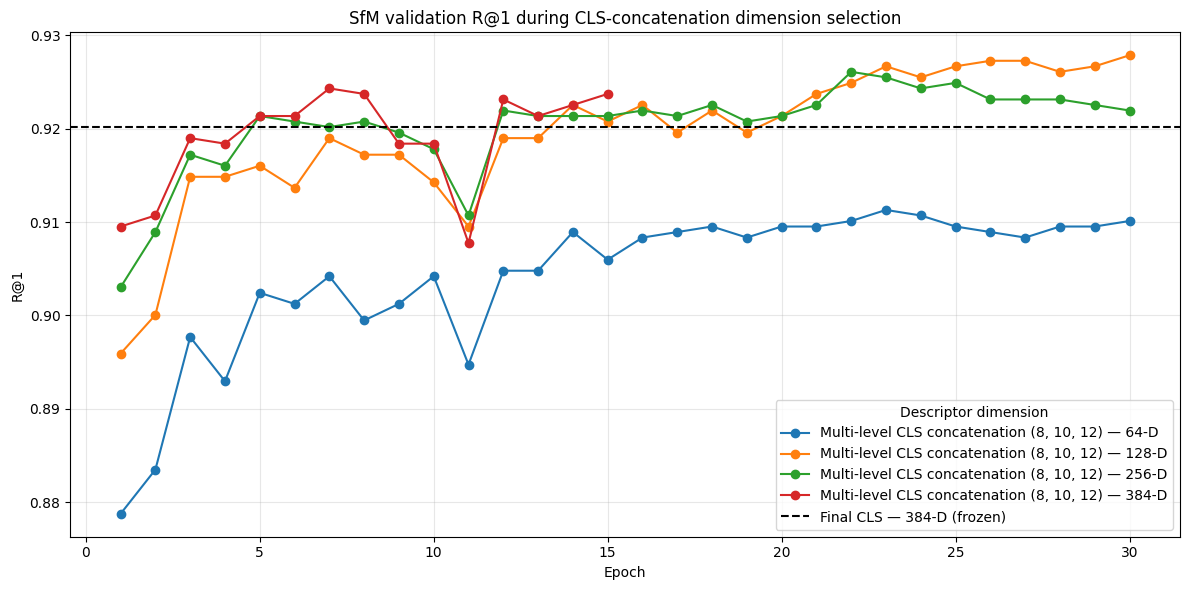

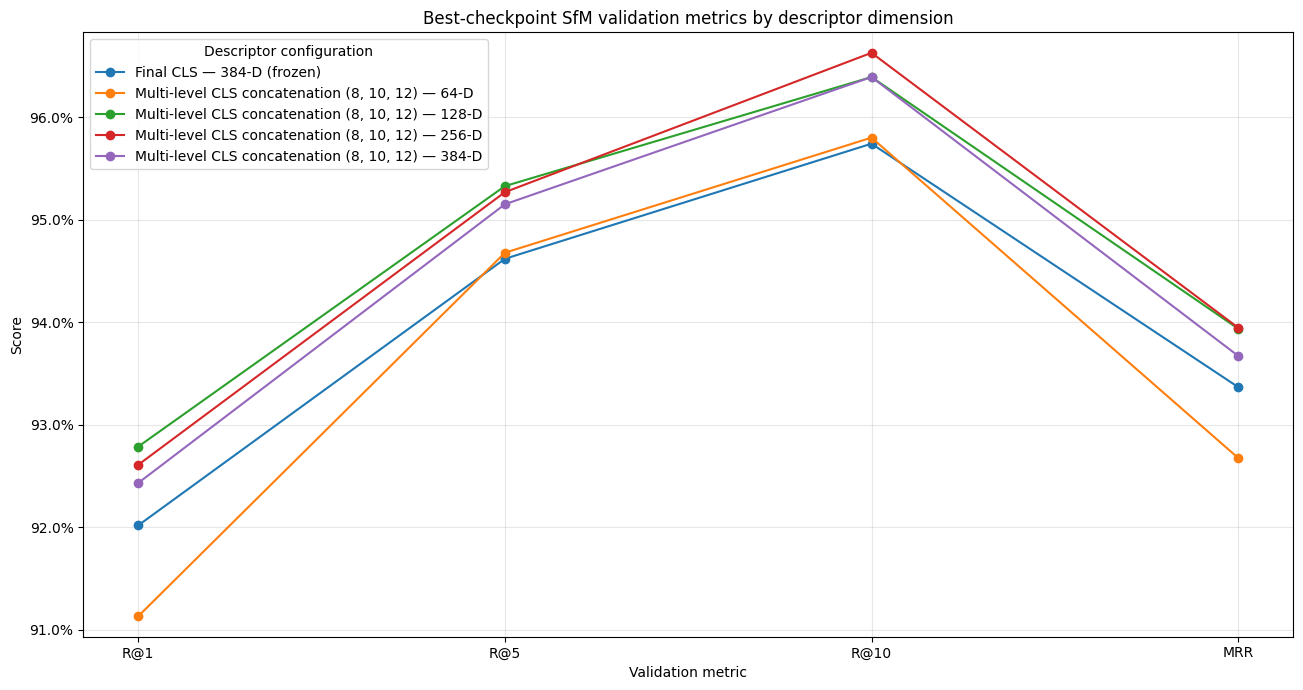

[{'configuration': 'Final CLS — 384-D (frozen)', 'descriptor_dimension': 384, 'trainable_parameter_count': 0, 'recall_at_1': 0.9201655824955648, 'recall_at_5': 0.9461856889414547, 'recall_at_10': 0.9574216439976345, 'mrr': 0.9336657129040622}, {'configuration': 'Multi-level CLS concatenation (8, 10, 12) — 64-D', 'descriptor_dimension': 64, 'trainable_parameter_count': 76096, 'descriptor_bytes_fp32': 256, 'descriptor_bytes_fp16': 128, 'recall_at_1': 0.9112950916617386, 'recall_at_5': 0.9467770549970431, 'recall_at_10': 0.9580130100532229, 'mrr': 0.9267497847536078}, {'configuration': 'Multi-level CLS concatenation (8, 10, 12) — 128-D', 'descriptor_dimension': 128, 'trainable_parameter_count': 149888, 'descriptor_bytes_fp32': 512, 'descriptor_bytes_fp16': 256, 'recall_at_1': 0.9278533412182141, 'recall_at_5': 0.9532820816085157, 'recall_at_10': 0.9639266706091071, 'mrr': 0.9393663735680484}, {'configuration': 'Multi-level CLS concatenation (8, 10, 12) — 256-D', 'descriptor_dimension': 25

In [7]:
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.ticker import PercentFormatter

missing = [spec['name'] for spec in DIMENSION_SPECS if spec['name'] not in dimension_results]
if missing:
    raise RuntimeError('Run every descriptor dimension before comparing: ' + ', '.join(missing))

history_series = {
    result['experiment_label']: SeriesData(
        x=[int(epoch['epoch']) + 1 for epoch in histories[name].epochs],
        y=[epoch['val_recall_at_1'] for epoch in histories[name].epochs],
    )
    for name, result in dimension_results.items()
}
figure, _ = plot_series(
    history_series,
    title='SfM validation R@1 during CLS-concatenation dimension selection',
    xlabel='Epoch',
    ylabel='R@1',
    legend_title='Descriptor dimension',
    horizontal_references={
        baseline_metrics['label']: HorizontalReference(baseline_metrics['recall_at_1'])
    },
    fig_size=(12, 6),
    save_path=ARTIFACT_RUN.path_for('figures/dimension_selection_validation_r1.png'),
)
display(figure)
plt.close(figure)

metric_definitions = (
    ('recall_at_1', 'R@1'),
    ('recall_at_5', 'R@5'),
    ('recall_at_10', 'R@10'),
    ('mrr', 'MRR'),
)
metric_positions = list(range(len(metric_definitions)))
selected_metric_series = {
    baseline_metrics['label']: SeriesData(
        x=metric_positions,
        y=[baseline_metrics[name] for name, _ in metric_definitions],
    ),
    **{
        result['experiment_label']: SeriesData(
            x=metric_positions,
            y=[result['best_epoch_metrics']['val_' + name] for name, _ in metric_definitions],
        )
        for result in dimension_results.values()
    },
}
all_metric_values = [
    value
    for series_data in selected_metric_series.values()
    for value in series_data.y
]
figure, axis = plot_series(
    selected_metric_series,
    title='Best-checkpoint SfM validation metrics by descriptor dimension',
    xlabel='Validation metric',
    ylabel='Score',
    legend_title='Descriptor configuration',
    fig_size=(13, 7),
    save_path=ARTIFACT_RUN.path_for('figures/dimension_selection_best_metrics.png'),
)
axis.set_xticks(metric_positions)
axis.set_xticklabels([label for _, label in metric_definitions])
axis.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
axis.set_ylim(min(all_metric_values) - 0.002, max(all_metric_values) + 0.002)
display(figure)
plt.close(figure)

dimension_comparison = [
    {
        'configuration': baseline_metrics['label'],
        'descriptor_dimension': baseline_metrics['descriptor_dimension'],
        'trainable_parameter_count': 0,
        **{name: baseline_metrics[name] for name, _ in metric_definitions},
    },
    *[
        {
            'configuration': result['experiment_label'],
            'descriptor_dimension': result['descriptor_dimension'],
            'trainable_parameter_count': result['trainable_parameter_count'],
            'descriptor_bytes_fp32': result['descriptor_bytes_fp32'],
            'descriptor_bytes_fp16': result['descriptor_bytes_fp16'],
            **{name: result['best_epoch_metrics']['val_' + name] for name, _ in metric_definitions},
        }
        for result in dimension_results.values()
    ],
]
ARTIFACT_RUN.write_json('dimension_comparison.json', dimension_comparison)
write_dimension_summary()
print(dimension_comparison)


## Manually lock the final SfM-selected model

Set the variable in the next cell only after inspecting the SfM-only dimension
comparison. Notebook 05 refuses to run without this final-model lock.


In [12]:
from cbir.cache import sha256_file
from cbir.utils import atomic_write_json

# Select manually after inspecting SfM-only dimension results. Example:
# FINAL_EXPERIMENT = 'cls_concat_128'
FINAL_EXPERIMENT = 'cls_concat_128'
if FINAL_EXPERIMENT is None:
    print('No final model locked yet. Set FINAL_EXPERIMENT after inspecting SfM-only results.')
else:
    if FINAL_EXPERIMENT not in dimension_results:
        raise KeyError('Choose a completed dimension experiment: ' + repr(tuple(dimension_results)))
    selected = dimension_results[FINAL_EXPERIMENT]
    checkpoint_path = Path(selected['persistent_checkpoint'])
    if not checkpoint_path.is_file():
        raise FileNotFoundError('Durable selected checkpoint is missing: ' + str(checkpoint_path))
    final_model = {
        'selected_on': 'Manual student decision after SfM-30k validation inspection only',
        'dimension_selection_notebook_run_id': ARTIFACT_RUN.run_id,
        'layer_selection_notebook_run_id': layer_selection['notebook_run_id'],
        'cache_fingerprint': reader.manifest.fingerprint,
        'selected_experiment': FINAL_EXPERIMENT,
        'experiment_label': selected['experiment_label'],
        'layer_indices_one_based': selected['layer_indices_one_based'],
        'descriptor_dimension': selected['descriptor_dimension'],
        'fusion_config': selected['fusion_config'],
        'training_config': selected['training_config'],
        'best_epoch': selected['best_epoch'],
        'best_metric': selected['best_metric'],
        'checkpoint_path': str(checkpoint_path),
        'checkpoint_sha256': sha256_file(checkpoint_path),
    }
    final_lock_path = PERSISTENT_ROOT / 'locked' / 'final_model.json'
    atomic_write_json(final_lock_path, final_model)
    ARTIFACT_RUN.write_json('final_model.json', final_model)
    print('Locked final SfM-selected model:', checkpoint_path)


Locked final SfM-selected model: /content/drive/MyDrive/lightweight-cbir/checkpoints/04/20260805T110014Z__nb-04__git-c58b5ea65d19__cfg-d4f7521f8b98/cls_concat_128/best.pt


## Publish Notebook 04 outputs to Drive


In [13]:
published_output = ARTIFACT_RUN.publish(DRIVE_OUTPUT_ROOT)
print('Validated notebook artifacts published to:', published_output)


Validated notebook artifacts published to: /content/drive/MyDrive/lightweight-cbir/notebook_outputs/04/20260805T110014Z__nb-04__git-c58b5ea65d19__cfg-d4f7521f8b98__rev-6148dda73be7
